# Build Task Bank — Named Entity Recognition

Samples from four NER datasets and converts each into **ExtractionTask** objects
defined in `models/task.py`.

| Dataset | Domain | Entity types | Split used |
|---------|--------|--------------|------------|
| [conll2003](https://huggingface.co/datasets/conll2003) | News wire | PER, ORG, LOC, MISC | validation |
| [wnut_17](https://huggingface.co/datasets/wnut_17) | Social media / Twitter | corporation, creative-work, group, location, person, product | test |
| [DFKI-SLT/few-nerd](https://huggingface.co/datasets/DFKI-SLT/few-nerd) (supervised) | Wikipedia & Wikinews | 66 fine-grained types (8 coarse) | test |
| [tner/bc5cdr](https://huggingface.co/datasets/tner/bc5cdr) | Biomedical literature | Chemical, Disease | test |

Each row becomes one `ExtractionTask`:
- **`input`** — the raw sentence / passage the model must tag
- **`expected`** — `[{"text": "...", "label": "..."}]` entity spans decoded from BIO tags
- **`entity_types`** — closed set of labels valid for that dataset
- **`rubric`** — hand-crafted per dataset reflecting its entity-type vocabulary

## 1. Imports & config

In [95]:
import json
import random
import sys
from datetime import date
from pathlib import Path
from pprint import pprint
from typing import Literal

import nltk
import textstat
from datasets import load_dataset

# Make project root importable from data_pipeline/
sys.path.append(str(Path("__file__").resolve().parent.parent))
from models.task import ExtractionTask, Task
from utils.pipeline_utils import (
    _readability_score,
    _lexical_density_score,
    infer_domain,
    annotate_pending,
    _NEEDS_REVIEW,
)

# ── Config ────────────────────────────────────────────────────────────────────
TASK_BANK   = Path("../task_bank")
SEED        = 42

# Per-dataset output files
OUT_CONLL    = TASK_BANK / "ner_conll_tasks.jsonl"
OUT_WNUT     = TASK_BANK / "ner_wnut_tasks.jsonl"
OUT_FEW_NERD = TASK_BANK / "ner_few_nerd_tasks.jsonl"
OUT_BC5CDR   = TASK_BANK / "ner_bc5cdr_tasks.jsonl"

# Combined sample — one file the user can optionally use
OUT_COMBINED = TASK_BANK / "ner_combined_tasks.jsonl"
N_COMBINED   = 1000   # samples drawn from each dataset for the combined file

In [ ]:
nltk.download("punkt",        quiet=True)
nltk.download("punkt_tab",    quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

## 2. Load datasets

In [ ]:
conll     = load_dataset("conll2003",          split="validation", trust_remote_code=True)
wnut      = load_dataset("wnut_17",            split="test",       trust_remote_code=True)
few_nerd  = load_dataset("DFKI-SLT/few-nerd", "supervised", split="test")
bc5cdr    = load_dataset("tner/bc5cdr",       split="test")

print("CoNLL-2003 validation :", len(conll),    " | columns:", conll.column_names)
print("WNUT-17 test          :", len(wnut),     " | columns:", wnut.column_names)
print("Few-NERD test         :", len(few_nerd), " | columns:", few_nerd.column_names)
print("BC5CDR test           :", len(bc5cdr),   " | columns:", bc5cdr.column_names)

In [ ]:
import pandas as pd

for name, ds in [("CoNLL-2003", conll), ("WNUT-17", wnut), ("Few-NERD", few_nerd), ("BC5CDR", bc5cdr)]:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    display(ds.to_pandas().head(5))

In [ ]:
# Inspect label-id maps for BIO datasets
print("CoNLL NER features:\n", conll.features["ner_tags"], "\n")
print("WNUT NER features:\n",  wnut.features["ner_tags"],  "\n")
print("Few-NERD NER features:\n", few_nerd.features["ner_tags"])

In [ ]:
# ── Inspect Few-NERD feature schema and a raw row ────────────────────────────
print("few_nerd features:")
print(few_nerd.features)
print()

fn_feat = few_nerd.features["ner_tags"]
print("ner_tags feature type :", type(fn_feat))
print("ner_tags.feature type :", type(fn_feat.feature))
print()

fn_inner = fn_feat.feature
if hasattr(fn_inner, "names"):
    print("ClassLabel names (first 10):", fn_inner.names[:10])
elif hasattr(fn_inner, "int2str"):
    print("int2str(0):", fn_inner.int2str(0))
else:
    print("No .names or .int2str -- feature is:", fn_inner)

print()
print("Raw row [0] ner_tags (first 10 ids):", few_nerd[0]["ner_tags"][:10])
print("Raw row [0] tokens   (first 10)    :", few_nerd[0]["tokens"][:10])

## 3. Shared BIO helpers  

BIO - Beginning Inside Outside

In [39]:
def decode_bio(tokens: list[str], tag_ids: list[int], id2label: dict[int, str]) -> list[dict[str, str]]:
    """
    Convert a BIO-tagged token sequence into a list of entity span dicts.

    Handles both:
    - Standard 2-part labels  B-PER / I-PER  -> label = "PER"
    - Fine-grained labels     B-location-GPE -> label = "location-GPE"
    - 'O' tags are skipped.
    """
    entities: list[dict[str, str]] = []
    current_tokens: list[str] = []
    current_label: str | None = None

    def flush():
        if current_tokens and current_label:
            entities.append({"text": " ".join(current_tokens), "label": current_label})

    for token, tag_id in zip(tokens, tag_ids):
        label_str = id2label[tag_id]

        if label_str == "O":
            flush()
            current_tokens, current_label = [], None
            continue

        prefix, _, entity_label = label_str.partition("-")

        if prefix == "B":
            flush()
            current_tokens  = [token]
            current_label   = entity_label
        elif prefix == "I" and entity_label == current_label:
            current_tokens.append(token)
        else:
            # Malformed I-tag (label mismatch or missing B) — start a new entity
            flush()
            current_tokens  = [token]
            current_label   = entity_label

    flush()
    return entities


def decode_io(tokens: list[str], tag_ids: list[int], id2label: dict[int, str]) -> list[dict[str, str]]:
    """
    Decode an IO-tagged sequence (no B-/I- prefixes) into entity span dicts.
    Consecutive tokens sharing the same non-O label are merged into one span.

    Example:  ["New", "York", "is", "beautiful"] with tags [4, 4, 0, 0]
              and id2label={0:"O", 4:"location"}  ->  [{"text": "New York", "label": "location"}]
    """
    entities: list[dict[str, str]] = []
    current_tokens: list[str] = []
    current_label: str | None = None

    def flush():
        if current_tokens and current_label:
            entities.append({"text": " ".join(current_tokens), "label": current_label})

    for token, tag_id in zip(tokens, tag_ids):
        label = id2label[tag_id]
        if label == "O":
            flush()
            current_tokens, current_label = [], None
        elif label == current_label:
            current_tokens.append(token)
        else:
            flush()
            current_tokens  = [token]
            current_label   = label

    flush()
    return entities


def assign_difficulty_ner(
    entities: list[dict[str, str]],
    text: str = "",
) -> Literal["easy", "medium", "hard"]:
    """
    Four NER-specific signals (weighted average):

    35%  multi-token span ratio
         Fraction of entities whose surface form spans >1 token.
         Multi-word entities (e.g. "New York City", "Goldman Sachs") are the
         primary source of boundary errors in NER — the model must get both the
         start and end right.

    30%  entity density
         Entities per token (normalised to 0-1 at 1 entity per 5 tokens).
         A sentence packed with entities is harder: the model must context-switch
         between multiple spans without missing or conflating them.

    20%  type diversity
         Distinct label count / 8 (capped at 1).
         More label types in one sentence means the model must discriminate
         finer-grained semantics simultaneously (e.g. PER vs ORG vs LOC all
         appearing in a single short sentence).

    15%  lexical density
         Content-word ratio from pipeline_utils._lexical_density_score.
         Information-dense prose (high noun/verb/adjective ratio) makes span
         boundaries harder to detect than syntactically simple sentences.

    Thresholds:  score < 0.35 -> easy  |  < 0.65 -> medium  |  else -> hard
    """
    if not entities:
        return "easy"

    # 1. Multi-token span ratio
    multi_token     = sum(1 for e in entities if len(e["text"].split()) > 1)
    multi_score     = multi_token / len(entities)

    # 2. Entity density  (1 entity per 5 tokens → score = 1.0)
    token_count     = max(len(text.split()), 1)
    density_score   = min(len(entities) / (token_count / 5.0), 1.0)

    # 3. Type diversity  (normalised by 8 — the max coarse-label count in Few-NERD)
    type_count      = len({e["label"] for e in entities})
    diverse_score   = min(type_count / 8.0, 1.0)

    # 4. Lexical density
    lex_score       = _lexical_density_score(text) if text.strip() else 0.3

    score = (
        0.35 * multi_score
        + 0.30 * density_score
        + 0.20 * diverse_score
        + 0.15 * lex_score
    )
    if score < 0.35:
        return "easy"
    if score < 0.65:
        return "medium"
    return "hard"

## 4. CoNLL-2003

News-wire text (Reuters). Entity types: **PER** (person), **ORG** (organisation),
**LOC** (location), **MISC** (miscellaneous — nationalities, events, etc.).

In [ ]:
CONLL_ENTITY_TYPES = ["LOC", "MISC", "ORG", "PER"]

CONLL_RUBRIC = (
    "Evaluate named entity extraction on CoNLL-2003 news text.\n"
    "Valid labels: PER (person names), ORG (organisations), "
    "LOC (locations, geo-political places), MISC (nationalities, events, products).\n\n"
    "Score on three dimensions (1-5 each):\n"
    "1. Precision  -- every extracted span is a true entity with the correct label.\n"
    "2. Recall     -- no expected entity was missed.\n"
    "3. Boundary   -- spans are exact (no over- or under-segmentation).\n"
    "Return JSON: {\"precision\": int, \"recall\": int, "
    "\"boundary\": int, \"overall\": float}"
)


def conll_row_to_task(row: dict, index: int) -> ExtractionTask | None:
    id2label = conll.features["ner_tags"].feature.int2str
    entities = decode_bio(row["tokens"], row["ner_tags"], {i: id2label(i) for i in range(9)})
    if not entities:
        return None
    text = " ".join(row["tokens"])
    return ExtractionTask(
        task_id      = f"ner_conll_val_{index:06d}",
        difficulty   = assign_difficulty_ner(entities, text),
        domain       = infer_domain(text),
        input        = text,
        expected     = entities,
        entity_types = CONLL_ENTITY_TYPES,
        rubric       = CONLL_RUBRIC,
        metadata     = {
            "source"     : "conll2003",
            "split"      : "validation",
            "original_id": row.get("id", index),
            "date_added" : str(date.today()),
        },
    )

In [72]:
N_CONLL = len(conll)
conll_tasks   = [t for i in range(N_CONLL) if (t := conll_row_to_task(conll[i], i)) is not None]
print(f"CoNLL: {len(conll_tasks)} tasks  ({N_CONLL - len(conll_tasks)} skipped -- no entities)")

CoNLL: 2605 tasks  (645 skipped -- no entities)


In [73]:
# ── Inspect skipped CoNLL sentences ──────────────────────────────────────────
# A sentence is skipped when every BIO tag is "O" (no entities at all).

id2label_conll = {i: conll.features["ner_tags"].feature.int2str(i)
                  for i in range(conll.features["ner_tags"].feature.num_classes)}

skipped = []
for i in range(N_CONLL):
    row = conll[i]
    entities = decode_bio(row["tokens"], row["ner_tags"], id2label_conll)
    if not entities:
        skipped.append((i, row["tokens"], row["ner_tags"]))

print(f"{len(skipped)} skipped sentences (all tags are 'O' — no entities present)\n")
for idx, tokens, tags in skipped[:10]:
    print(f"  row {idx:5d}: {' '.join(tokens[:14])}{'...' if len(tokens) > 14 else ''}")
if len(skipped) > 10:
    print(f"  ... and {len(skipped) - 10} more")

645 skipped sentences (all tags are 'O' — no entities present)

  row    34: said on Friday .
  row    36: four one-day warm-up matches at the start of the tour .
  row    37: The tourists will play nine first-class matches against
  row    41: Tour itinerary :
  row    42: May
  row    55: days )
  row    57: June
  row    59: June 11-13 v a first class county ( to be confirmed )
  row    64: July
  row    71: August
  ... and 635 more


## 5. WNUT-17

Emerging-entity dataset from Twitter/social media.  Harder than CoNLL because of
informal spelling, hashtags, and newly coined entity names.
Types: **corporation**, **creative-work**, **group**, **location**, **person**, **product**.

In [ ]:
WNUT_ENTITY_TYPES = ["corporation", "creative-work", "group", "location", "person", "product"]

WNUT_RUBRIC = (
    "Evaluate named entity extraction on WNUT-17 social-media text (tweets, Reddit, etc.).\n"
    "Valid labels: corporation, creative-work, group, location, person, product.\n"
    "Note: entities are *emerging* (novel names, non-standard spelling) -- "
    "partial credit should NOT be given for guessing a wrong label.\n\n"
    "Score on three dimensions (1-5 each):\n"
    "1. Precision  -- every extracted span is a true entity with the correct label.\n"
    "2. Recall     -- no expected entity was missed.\n"
    "3. Boundary   -- spans are exact (no over- or under-segmentation).\n"
    "Return JSON: {\"precision\": int, \"recall\": int, "
    "\"boundary\": int, \"overall\": float}"
)


def wnut_row_to_task(row: dict, index: int) -> ExtractionTask | None:
    id2label = wnut.features["ner_tags"].feature.int2str
    n_labels = wnut.features["ner_tags"].feature.num_classes
    entities = decode_bio(row["tokens"], row["ner_tags"], {i: id2label(i) for i in range(n_labels)})
    if not entities:
        return None
    text = " ".join(row["tokens"])
    return ExtractionTask(
        task_id      = f"ner_wnut_test_{index:06d}",
        difficulty   = assign_difficulty_ner(entities, text),
        domain       = infer_domain(text),
        input        = text,
        expected     = entities,
        entity_types = WNUT_ENTITY_TYPES,
        rubric       = WNUT_RUBRIC,
        metadata     = {
            "source"     : "wnut_17",
            "split"      : "test",
            "original_id": index,
            "date_added" : str(date.today()),
        },
    )

In [75]:
N_WNUT = len(wnut)
wnut_tasks   = [t for i in range(N_WNUT) if (t := wnut_row_to_task(wnut[i], i)) is not None]
print(f"WNUT-17: {len(wnut_tasks)} tasks  ({N_WNUT - len(wnut_tasks)} skipped -- no entities)")

WNUT-17: 689 tasks  (598 skipped -- no entities)


In [ ]:
# ── Inspect skipped WNUT sentences ──────────────────────────────────────────
# A sentence is skipped when every BIO tag is "O" (no entities at all).

id2label_wnut = {i: wnut.features["ner_tags"].feature.int2str(i)
                  for i in range(wnut.features["ner_tags"].feature.num_classes)}

skipped = []
for i in range(N_WNUT):
    row = wnut[i]
    entities = decode_bio(row["tokens"], row["ner_tags"], id2label_wnut)
    if not entities:
        skipped.append((i, row["tokens"], row["ner_tags"]))

print(f"{len(skipped)} skipped sentences (all tags are 'O' — no entities present)\n")
for idx, tokens, tags in skipped[:10]:
    print(f"  row {idx:5d}: {' '.join(tokens[:14])}{'...' if len(tokens) > 14 else ''}")
if len(skipped) > 10:
    print(f"  ... and {len(skipped) - 10} more")

598 skipped sentences (all tags are 'O' — no entities present)

  row     2: & gt ; * The army on Thursday recovered the bodies of ten of...
  row     3: & gt ; * The four civilians killed included two children of a family...
  row    13: ^ Function ^ : ^ I ^ post ^ the ^ article ' s...
  row    14: [ ^ I ^ accept ^ commands !
  row    16: [ IMAGE ] ( http://images.indianexpress.com/2015/05/drdo-logo-thumb.jpg?w=480 )
  row    19: ( File Photo )
  row    24: “ In Navy , advisories on mental health are issued from time to time...
  row    25: ^ Function ^ : ^ I ^ post ^ the ^ article ' s...
  row    26: [ ^ I ^ accept ^ commands !
  row    27: & gt ; Umm , where are all these alleged criticisms ?
  ... and 588 more


## 6. Few-NERD (supervised)

Wikipedia & Wikinews; 66 fine-grained entity types nested under 8 coarse types
(person, location, organization, building, art, product, event, other).
We preserve the fine-grained label (e.g. `location-GPE`) because it is richer
than CoNLL; the `entity_types` list in each task enumerates only the labels
that actually appear in that sample.

In [77]:
# Build id->label map from the ClassLabel .names list (robust across datasets versions)
_few_nerd_feature = few_nerd.features["ner_tags"].feature
if hasattr(_few_nerd_feature, "names"):
    _fn_id2label = dict(enumerate(_few_nerd_feature.names))
elif hasattr(_few_nerd_feature, "int2str"):
    _fn_id2label = {i: _few_nerd_feature.int2str(i) for i in range(_few_nerd_feature.num_classes)}
else:
    raise ValueError(f"Cannot build id2label: unsupported feature type {type(_few_nerd_feature)}")
print(f"Few-NERD label map: {len(_fn_id2label)} labels, first 6: {list(_fn_id2label.items())[:6]}")

Few-NERD label map: 9 labels, first 6: [(0, 'O'), (1, 'art'), (2, 'building'), (3, 'event'), (4, 'location'), (5, 'organization')]


In [ ]:
FEW_NERD_ENTITY_TYPES = [
    "art", "building", "event", "location",
    "organization", "other", "person", "product",
]

FEW_NERD_RUBRIC = (
    "Evaluate named entity extraction on Few-NERD Wikipedia/Wikinews text.\n"
    "Labels use a coarse-fine format, e.g. 'person-actor', 'location-GPE', "
    "'organization-company'.  Both the span boundary AND the full fine-grained "
    "label must be correct.\n\n"
    "Score on three dimensions (1-5 each):\n"
    "1. Precision     -- every extracted span is a true entity with the exact fine-grained label.\n"
    "2. Recall        -- no expected entity was missed.\n"
    "3. Label granularity -- penalise coarse-only labels "
    "(e.g. 'person' instead of 'person-actor').\n"
    "Return JSON: {\"precision\": int, \"recall\": int, "
    "\"label_granularity\": int, \"overall\": float}"
)


def few_nerd_row_to_task(row: dict, index: int) -> ExtractionTask | None:
    entities = decode_io(row["tokens"], row["ner_tags"], _fn_id2label)
    if not entities:
        return None
    text         = " ".join(row["tokens"])
    entity_types = FEW_NERD_ENTITY_TYPES                    # fixed closed set for this dataset
    return ExtractionTask(
        task_id         = f"ner_fewnerd_test_{index:06d}",
        difficulty      = assign_difficulty_ner(entities, text),
        domain          = infer_domain(text),
        input           = text,
        expected        = entities,
        entity_types    = entity_types,
        rubric          = FEW_NERD_RUBRIC,
        metadata        = {
            "source"     : "DFKI-SLT/few-nerd",
            "config"     : "supervised",
            "split"      : "test",
            "original_id": index,
            "date_added" : str(date.today()),
        },
    )

Few-NERD label map: 9 labels, first 6: [(0, 'O'), (1, 'art'), (2, 'building'), (3, 'event'), (4, 'location'), (5, 'organization')]


In [ ]:
N_FEW_NERD = len(few_nerd)
few_nerd_tasks   = [t for i in range(N_FEW_NERD) if (t := few_nerd_row_to_task(few_nerd[i], i)) is not None]

WNUT-FEW-NERD: 32565 tasks  (-31278 skipped -- no entities)


In [102]:
print(f"FEW-NERD: {len(few_nerd_tasks)} tasks  ({N_FEW_NERD- len(few_nerd_tasks)} skipped -- no entities)")

FEW-NERD: 32565 tasks  (5083 skipped -- no entities)


## 7. BC5CDR (tner)

PubMed abstracts annotated for **Chemical** and **Disease** entities.
`tner/bc5cdr` is a Parquet-hosted version with standard BIO integer tags —
no custom script or extra dependencies required.
Uses the same `decode_bio` helper as CoNLL and WNUT.

In [78]:
BC5CDR_ENTITY_TYPES = ["Chemical", "Disease"]

BC5CDR_RUBRIC = (
    "Evaluate named entity extraction on BC5CDR biomedical abstracts (PubMed).\n"
    "Valid labels: Chemical (drug names, chemical compounds), "
    "Disease (disease names, symptoms, adverse drug reactions).\n"
    "Biomedical abbreviations count as valid spans if the full form also appears.\n\n"
    "Score on three dimensions (1-5 each):\n"
    "1. Precision  -- every extracted span is a true entity with the correct label.\n"
    "2. Recall     -- no expected entity was missed.\n"
    "3. Boundary   -- spans match the reference exactly "
    "(neither the determiner nor a trailing modifier is included).\n"
    "Return JSON: {\"precision\": int, \"recall\": int, "
    "\"boundary\": int, \"overall\": float}"
)

# tner/bc5cdr uses the same BIO integer tag scheme as CoNLL/WNUT.
# Tags: 0=O, 1=B-Chemical, 2=I-Chemical, 3=B-Disease, 4=I-Disease
_bc5_id2label = {0: "O", 1: "B-Chemical", 2: "I-Chemical", 3: "B-Disease", 4: "I-Disease"}


def bc5cdr_row_to_task(row: dict, index: int) -> ExtractionTask | None:
    entities = decode_bio(row["tokens"], row["tags"], _bc5_id2label)
    if not entities:
        return None
    text = " ".join(row["tokens"])
    return ExtractionTask(
        task_id           = f"ner_bc5cdr_test_{index:06d}",
        difficulty        = assign_difficulty_ner(entities, text),
        domain            = "health",
        input             = text,
        expected          = entities,
        entity_types      = BC5CDR_ENTITY_TYPES,
        rubric            = BC5CDR_RUBRIC,
        metadata          = {
            "source"     : "tner/bc5cdr",
            "split"      : "test",
            "original_id": index,
            "date_added" : str(date.today()),
        },
    )

In [79]:
N_BC5CDR = len(bc5cdr)
bc5_tasks   = [t for i in range(N_BC5CDR) if (t := bc5cdr_row_to_task(bc5cdr[i], i)) is not None]
print(f"BC5CDR: {len(bc5_tasks)} tasks  ({N_BC5CDR - len(bc5_tasks)} skipped -- no entities)")

BC5CDR: 4140 tasks  (1725 skipped -- no entities)


In [94]:
skipped = []
for i in range(N_BC5CDR):
    row = bc5cdr[i]
    entities = decode_bio(row["tokens"], row["tags"], _bc5_id2label)
    if not entities:
        skipped.append((i, row["tokens"]))

print(f"{len(skipped)} skipped sentences (all tags are 'O' -- no entities present)\n")
for idx, tokens in skipped[:10]:
    print(f"  row {idx:5d}: {' '.join(tokens[:14])}{'...' if len(tokens) > 14 else ''}")
if len(skipped) > 10:
    print(f"  ... and {len(skipped) - 10} more")

1725 skipped sentences (all tags are 'O' -- no entities present)

  row     1: A series of six cases .
  row    20: METHODS : This was a cross - sectional study conducted concurrently at a teaching...
  row    22: I .
  row    23: N .
  row    25: The information on sociodemographic background and drug use history was obtained from interview or...
  row    26: RESULTS : Of 292 subjects , 47 .
  row    30: 18 , 95 CI = 2 .
  row    31: 612 - 19 .
  row    33: 807 , 95 CI = 5 .
  row    34: 194 - 36 .
  ... and 1715 more


In [90]:
bc5cdr.features["tags"].feature

Value(dtype='int32', id=None)

## 10. Inspect distributions

In [110]:
conll_dicts    = [t.model_dump() for t in conll_tasks]
wnut_dicts     = [t.model_dump() for t in wnut_tasks]
few_nerd_dicts = [t.model_dump() for t in few_nerd_tasks]
bc5cdr_dicts   = [t.model_dump() for t in bc5_tasks]

In [111]:
from collections import Counter

datasets_dict = {
    "CoNLL-2003" : conll_dicts,
    "WNUT-17"    : wnut_dicts,
    "Few-NERD"   : few_nerd_dicts,
    "BC5CDR"     : bc5cdr_dicts,
}

print(f"{'Dataset':<14} {'easy':>6} {'medium':>8} {'hard':>6} {'total':>7}")
print("-" * 40)
for name, tasks in datasets_dict.items():
    c = Counter(t["difficulty"] for t in tasks)
    print(f"{name:<14} {c['easy']:>6} {c['medium']:>8} {c['hard']:>6} {len(tasks):>7}")

Dataset          easy   medium   hard   total
----------------------------------------
CoNLL-2003        680     1544    381    2605
WNUT-17           316      304     69     689
Few-NERD         5505    21601   5459   32565
BC5CDR           2304     1823     13    4140


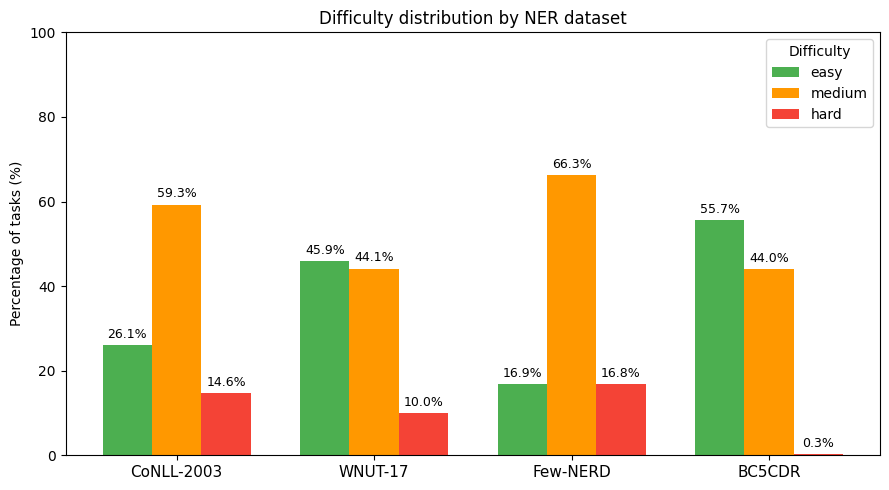

In [117]:
import matplotlib.pyplot as plt
import numpy as np

datasets_dict = {
    "CoNLL-2003" : conll_dicts,
    "WNUT-17"    : wnut_dicts,
    "Few-NERD"   : few_nerd_dicts,
    "BC5CDR"     : bc5cdr_dicts,
}

difficulties = ["easy", "medium", "hard"]
colors       = {"easy": "#4caf50", "medium": "#ff9800", "hard": "#f44336"}

names  = list(datasets_dict.keys())
x      = np.arange(len(names))
width  = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

for j, diff in enumerate(difficulties):
    totals = [len(datasets_dict[n]) for n in names]
    counts = [
        sum(1 for t in datasets_dict[n] if t["difficulty"] == diff) / totals[i] * 100
        for i, n in enumerate(names)
    ]
    bars   = ax.bar(x + j * width, counts, width, label=diff, color=colors[diff])
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Percentage of tasks (%)")
ax.set_title("Difficulty distribution by NER dataset")
ax.legend(title="Difficulty")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 10. Save to JSONL

Each dataset is saved to its own file. A combined sample (`ner_combined_tasks.jsonl`) is also written — `N_COMBINED` rows drawn from each dataset, shuffled together.

In [118]:
import random as _random

TASK_BANK.mkdir(parents=True, exist_ok=True)

# Save each dataset independently
for out_path, tasks in [
    (OUT_CONLL,    conll_dicts),
    (OUT_WNUT,     wnut_dicts),
    (OUT_FEW_NERD, few_nerd_dicts),
    (OUT_BC5CDR,   bc5cdr_dicts),
]:
    with out_path.open("w", encoding="utf-8") as f:
        for task in tasks:
            f.write(json.dumps(task, ensure_ascii=False) + "\n")
    print(f"Saved {len(tasks):>4} tasks -> {out_path.name}")

# Save combined sample — N_COMBINED rows drawn from each dataset
_random.seed(SEED)
combined = [
    task
    for tasks in [conll_dicts, wnut_dicts, few_nerd_dicts, bc5cdr_dicts]
    for task in _random.sample(tasks, min(N_COMBINED, len(tasks)))
]
_random.shuffle(combined)
with OUT_COMBINED.open("w", encoding="utf-8") as f:
    for task in combined:
        f.write(json.dumps(task, ensure_ascii=False) + "\n")
print(f"\nSaved {len(combined):>4} tasks -> {OUT_COMBINED.name}  (combined sample)")

Saved 2605 tasks -> ner_conll_tasks.jsonl
Saved  689 tasks -> ner_wnut_tasks.jsonl
Saved 32565 tasks -> ner_few_nerd_tasks.jsonl
Saved 4140 tasks -> ner_bc5cdr_tasks.jsonl

Saved 3689 tasks -> ner_combined_tasks.jsonl  (combined sample)


## 11. Reload & validate round-trip

In [119]:
from pydantic import TypeAdapter

adapter = TypeAdapter(Task)

for out_path in [OUT_CONLL, OUT_WNUT, OUT_FEW_NERD, OUT_BC5CDR, OUT_COMBINED]:
    loaded = []
    with out_path.open(encoding="utf-8") as f:
        for line in f:
            loaded.append(adapter.validate_json(line))
    all_extraction = all(isinstance(t, ExtractionTask) for t in loaded)
    print(f"{out_path.name:<35} {len(loaded):>4} tasks  all ExtractionTask: {all_extraction}")

ner_conll_tasks.jsonl               2605 tasks  all ExtractionTask: True
ner_wnut_tasks.jsonl                 689 tasks  all ExtractionTask: True
ner_few_nerd_tasks.jsonl            32565 tasks  all ExtractionTask: True
ner_bc5cdr_tasks.jsonl              4140 tasks  all ExtractionTask: True
ner_combined_tasks.jsonl            3689 tasks  all ExtractionTask: True
